# 📌 Project Overview
This notebook demonstrates a complete Machine Learning workflow to predict health conditions ('fit', 'at-risk', 'unhealthy') based on various physiological and lifestyle parameters. The process includes data loading, extensive data cleaning, exploratory data analysis, feature engineering, model training with multiple algorithms, evaluation, and saving the best-performing model.

In [118]:
!pip install tensorflow

import tensorflow as tf

print(tf.__version__)
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("GPU is available and enabled!")
else:
    print("No GPU device found. Using CPU.")

2.20.0
GPU is available and enabled!


### Check for GPU Availability
This code block checks if a GPU is available for TensorFlow operations and configures it to allow memory growth. If no GPU is found, it defaults to using the CPU.

# 📚 Import Required Libraries
This section imports all the necessary Python libraries for data manipulation, visualization, machine learning, and utility functions. TensorFlow is imported for potential deep learning tasks, while pandas, numpy, matplotlib, and seaborn are used for data handling and plotting. Scikit-learn modules are essential for model building, preprocessing, and evaluation.

In [119]:
import tensorflow as tf

try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print('Running on TPU ', tpu.master())
except ValueError:
    tpu = None

if tpu:
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print("TPU is available and enabled!")
else:
    strategy = tf.distribute.get_strategy()
    print("No TPU device found. Using default strategy (usually GPU or CPU).")


No TPU device found. Using default strategy (usually GPU or CPU).


### Check for TPU Availability
This section attempts to detect and initialize a TPU (Tensor Processing Unit) for distributed training, which can significantly speed up deep learning tasks. If a TPU is not available, it defaults to the available GPU or CPU.

In [120]:
print(tf.config.list_logical_devices())
print(tf.config.list_physical_devices())


[LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### List Available Devices
This cell prints the logical and physical devices recognized by TensorFlow, confirming which processors (CPU, GPU, TPU) are configured and ready for use.

In [1]:
import pandas as pd

# 📂 Load Dataset
In this section, we load the training and testing datasets from CSV files into pandas DataFrames. These datasets contain various health-related features and the target variable 'health_condition'.

In [122]:
train=pd.read_csv("/content/train (1).csv")
test=pd.read_csv("/content/test (1).csv")

In [123]:
train

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


# 🔍 Initial Data Exploration
This section performs initial exploratory data analysis (EDA) to understand the structure, content, and basic statistics of the training dataset. It helps in identifying potential issues like missing values, data types, and the distribution of the target variable.

In [124]:
train['health_condition'].value_counts()

,count
health_condition,
at-risk,592561
unhealthy,57724
fit,39803


### Target Variable Distribution
This output shows the class distribution of the 'health_condition' target variable in the original training dataset. This is crucial for understanding class imbalance before balancing techniques are applied.

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

### Distribution of Numerical Features (Before Outlier Handling)
These box plots visualize the distribution of each numerical feature in the training dataset. They help identify outliers and the spread of data, which informs subsequent data cleaning steps.

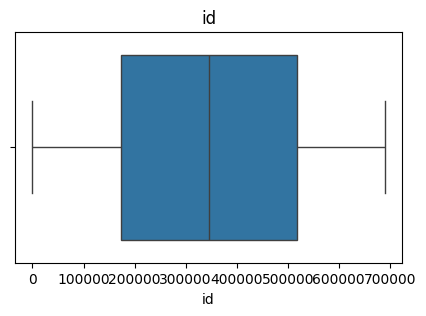

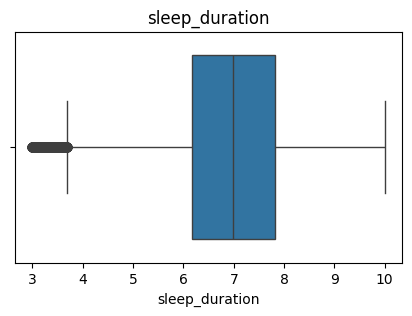

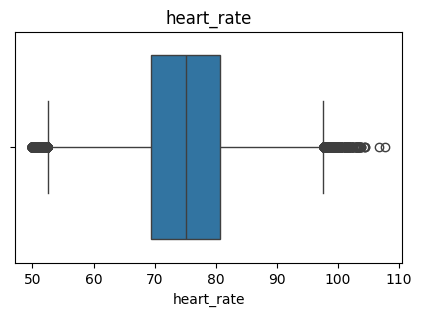

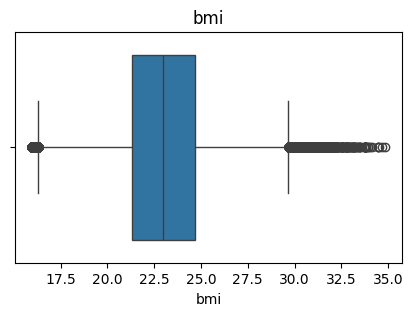

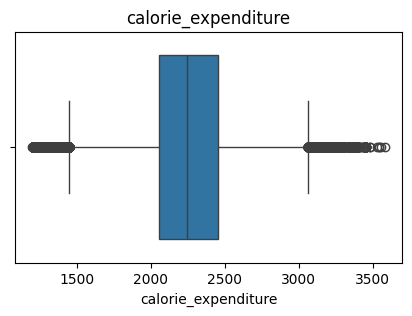

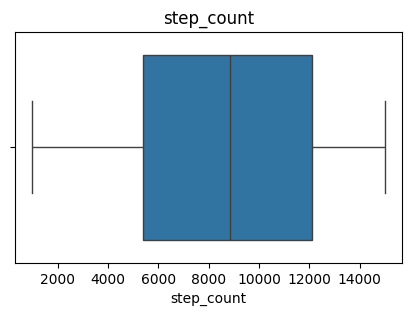

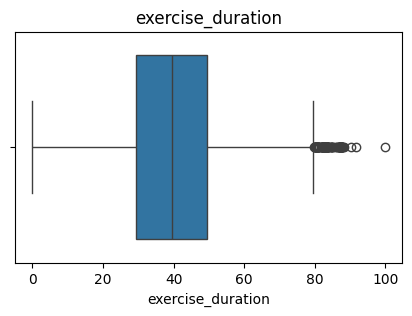

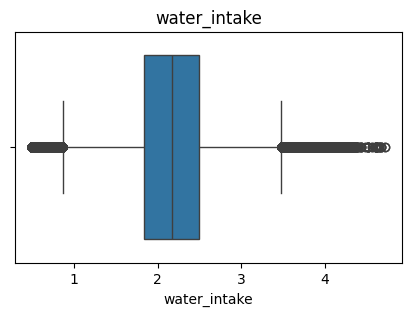

In [126]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns
for i in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=train[i])
    plt.title(i)
    plt.show()

# 🧹 Data Cleaning
This section focuses on handling outliers in numerical features using the Interquartile Range (IQR) method. Outliers can negatively impact model performance, so capping them helps in creating a more robust dataset.

In [127]:
import numpy as np
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    train[col] = np.clip(train[col], lower_bound, upper_bound)
    print(f"Capping applied to '{col}'. Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

print("\nAll numerical columns have been capped for outliers.")

Capping applied to 'id'. Lower bound: -345043.50, Upper bound: 1035130.50
Capping applied to 'sleep_duration'. Lower bound: 3.69, Upper bound: 10.28
Capping applied to 'heart_rate'. Lower bound: 52.45, Upper bound: 97.65
Capping applied to 'bmi'. Lower bound: 16.31, Upper bound: 29.67
Capping applied to 'calorie_expenditure'. Lower bound: 1448.50, Upper bound: 3060.50
Capping applied to 'step_count'. Lower bound: -4698.50, Upper bound: 22201.50
Capping applied to 'exercise_duration'. Lower bound: -1.10, Upper bound: 79.70
Capping applied to 'water_intake'. Lower bound: 0.85, Upper bound: 3.49

All numerical columns have been capped for outliers.


### Distribution of Numerical Features (After Outlier Capping)
These box plots display the distributions of numerical features in the training dataset after applying outlier capping. Comparing these to the previous plots shows the effect of the capping process.

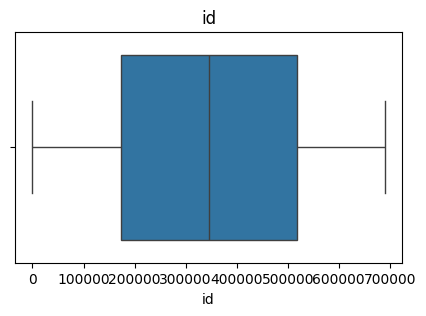

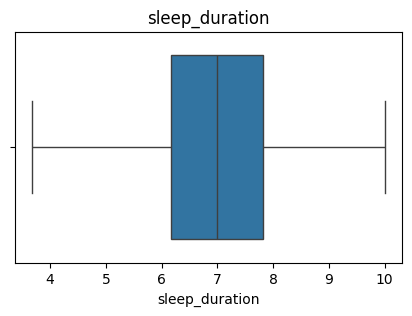

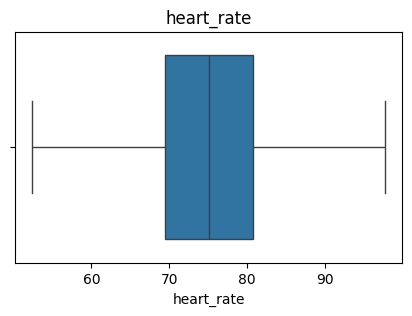

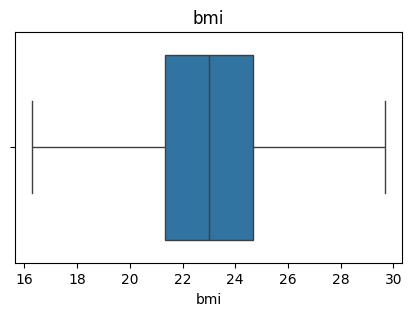

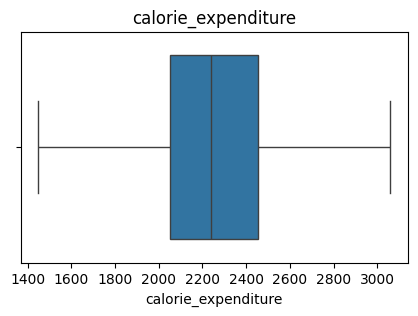

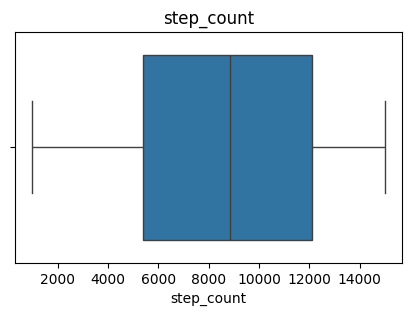

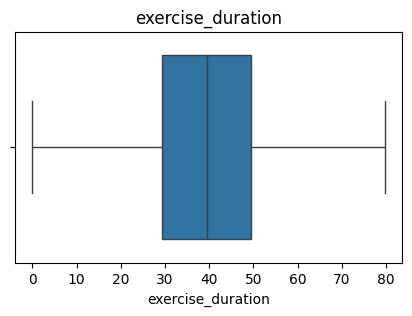

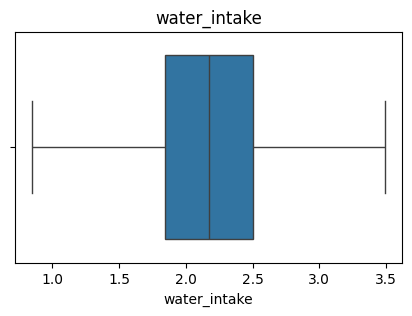

In [128]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns
for i in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=train[i])
    plt.title(i)
    plt.show()

In [129]:
test

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295748,985836,7.13,77.5,22.20,2221.0,13981.0,65.6,2.17,balanced,low,average,active,occasional,other
295749,985837,6.25,69.5,20.93,2242.0,2370.0,23.6,1.98,balanced,NaN,average,moderate,yes,female
295750,985838,NaN,77.0,23.62,2111.0,7647.0,25.1,2.18,veg,high,average,sedentary,no,other
295751,985839,7.25,66.3,21.47,2009.0,4672.0,25.1,2.02,veg,high,poor,moderate,no,female


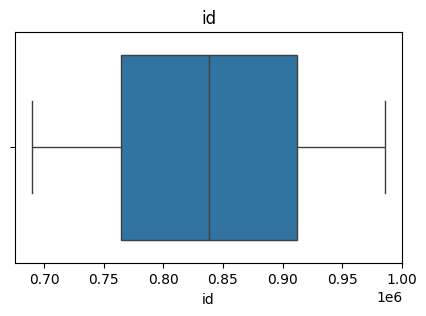

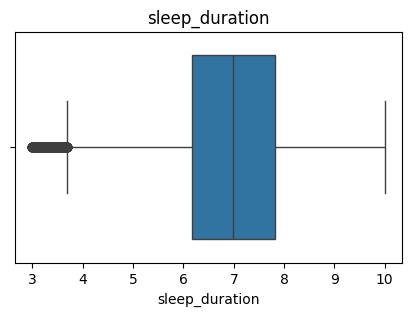

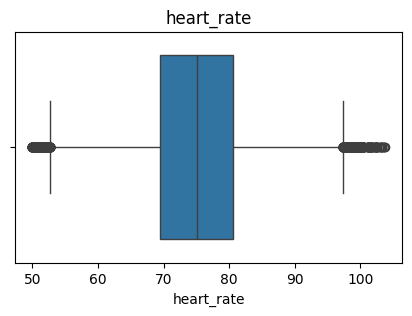

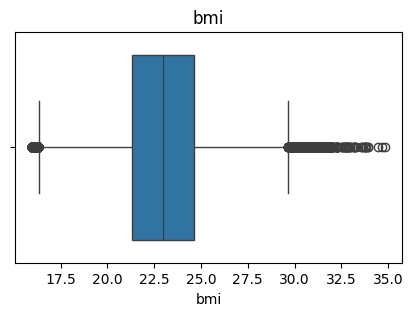

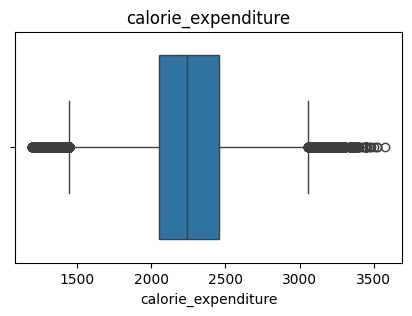

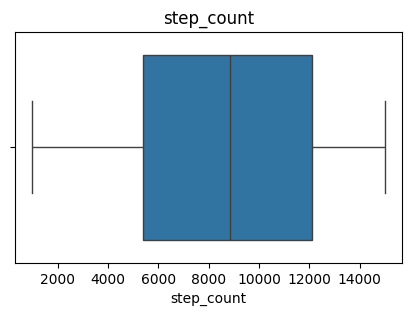

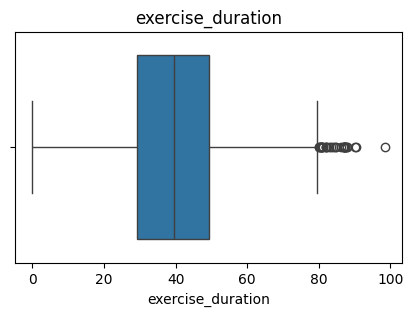

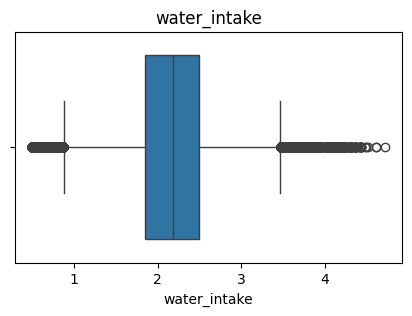

In [130]:
num_cols = test.select_dtypes(include=['int64', 'float64']).columns
for i in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=test[i])
    plt.title(i)
    plt.show()

In [131]:
import numpy as np
for col in num_cols:
    Q1 = test[col].quantile(0.25)
    Q3 =test[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    test[col] = np.clip(train[col], lower_bound, upper_bound)
    print(f"Capping applied to '{col}'. Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

print("\nAll numerical columns have been capped for outliers.")

Capping applied to 'id'. Lower bound: 542212.00, Upper bound: 1133716.00
Capping applied to 'sleep_duration'. Lower bound: 3.69, Upper bound: 10.28
Capping applied to 'heart_rate'. Lower bound: 52.60, Upper bound: 97.40
Capping applied to 'bmi'. Lower bound: 16.33, Upper bound: 29.64
Capping applied to 'calorie_expenditure'. Lower bound: 1447.50, Upper bound: 3059.50
Capping applied to 'step_count'. Lower bound: -4695.00, Upper bound: 22209.00
Capping applied to 'exercise_duration'. Lower bound: -1.10, Upper bound: 79.70
Capping applied to 'water_intake'. Lower bound: 0.88, Upper bound: 3.47

All numerical columns have been capped for outliers.


### Training Data Information
This provides a concise summary of the DataFrame, including the column names, their non-null counts, and data types. It helps to quickly check for missing values and correct data types.

In [132]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

### Missing Values in Training Data
This output shows the count of missing values for each column in the training dataset. This information is vital for deciding on appropriate imputation strategies.

In [133]:
train.isnull().sum()

,0
id,0
health_condition,0
sleep_duration,75999
heart_rate,7833
bmi,13898
calorie_expenditure,52853
step_count,13916
exercise_duration,6901
water_intake,43477
diet_type,6901


### Missing Value Percentage in Training Data
This table displays the percentage of missing values for each column, ordered from highest to lowest. It helps prioritize which columns need attention for imputation, excluding columns with too many missing values (over 60%).

In [134]:
NaN = (train.isnull().sum() / len(train) * 100).reset_index()
NaN.columns=['Column','NaN_per']
NaN = NaN[NaN["NaN_per"] < 60].sort_values("NaN_per",ascending=False)
print(NaN)


                     Column    NaN_per
10             stress_level  12.000064
2            sleep_duration  11.012943
11            sleep_quality   8.452690
5       calorie_expenditure   7.658878
8              water_intake   6.300211
12  physical_activity_level   5.306715
13          smoking_alcohol   4.141791
14                   gender   3.097141
6                step_count   2.016554
4                       bmi   2.013946
3                heart_rate   1.135073
9                 diet_type   1.000017
7         exercise_duration   1.000017
0                        id   0.000000
1          health_condition   0.000000


In [135]:
train['health_condition'].value_counts()

,count
health_condition,
at-risk,592561
unhealthy,57724
fit,39803


### Target Variable Distribution (Original)
This cell re-confirms the imbalanced distribution of the target variable 'health_condition' in the original training set, before any balancing operations.

In [136]:
at_risk = train[train["health_condition"] == "at-risk"].sample(
    n=40000,
    random_state=42,
    replace=True
)

unhealthy = train[train["health_condition"] == "unhealthy"].sample(
    n=40000,
    random_state=42,
    replace=True
)

fit = train[train["health_condition"] == "fit"].sample(
    n=39803,
    random_state=42,
    replace=True
)

train = pd.concat([at_risk, unhealthy, fit], ignore_index=True)

train = train.sample(frac=1, random_state=42).reset_index(drop=True)

print(train["health_condition"].value_counts())

health_condition
unhealthy    40000
at-risk      40000
fit          39803
Name: count, dtype: int64


### Balancing the Dataset
To address class imbalance in the `health_condition` target variable, this code uses an oversampling technique for the 'unhealthy' and 'at-risk' classes to match the count of the 'fit' class. This creates a more balanced dataset for training, which can prevent the model from being biased towards the majority class.

In [137]:
aa=train[train['health_condition'] == 'fit'].isnull().sum()
aa


,0
id,0
health_condition,0
sleep_duration,4380
heart_rate,461
bmi,1109
calorie_expenditure,3072
step_count,776
exercise_duration,419
water_intake,2539
diet_type,345


### Missing Values in 'fit' Health Condition
This shows the number of missing values for each feature specifically within the 'fit' health condition class after balancing. This helps to confirm if imputation is still needed for this subset.

In [138]:
aa=train[train['health_condition'] == 'unhealthy'].isnull().sum()
aa


,0
id,0
health_condition,0
sleep_duration,4382
heart_rate,429
bmi,279
calorie_expenditure,3091
step_count,789
exercise_duration,417
water_intake,2573
diet_type,421


### Missing Values in 'unhealthy' Health Condition
This shows the number of missing values for each feature specifically within the 'unhealthy' health condition class after balancing. This helps to confirm if imputation is still needed for this subset.

In [139]:
aa=train[train['health_condition'] == 'at-risk'].isnull().sum()
aa


,0
id,0
health_condition,0
sleep_duration,4440
heart_rate,481
bmi,838
calorie_expenditure,3078
step_count,797
exercise_duration,427
water_intake,2547
diet_type,430


### Missing Values in 'at-risk' Health Condition
This shows the number of missing values for each feature specifically within the 'at-risk' health condition class after balancing. This helps to confirm if imputation is still needed for this subset.

In [140]:
train.duplicated().sum()

np.int64(27048)

### Duplicate Values in Training Data
This cell calculates and prints the total number of duplicate rows in the training dataset. Handling duplicates is an important step in data cleaning to ensure data integrity and prevent overfitting.

### Imputing Missing Numerical Values
This code block imputes missing values in numerical columns of the training data using the median. The median is a robust measure that is less sensitive to outliers compared to the mean, making it suitable for skewed distributions.

In [141]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    if col != 'health_condition':
        median = train[col].median()
        train[col] = train[col].fillna(median)

### Verify No Missing Numerical Values
This cell checks if all missing values in numerical columns have been successfully imputed. A result of 0 confirms that there are no remaining missing values in these columns.

In [142]:
num_cols.isnull().sum()

np.int64(0)

### Imputing Missing Categorical Values
This code imputes missing values in categorical columns by replacing them with the string "Unknown". This ensures that all categorical features are complete and can be processed by encoding techniques.

In [143]:
cat_cols = train.select_dtypes(include='object').columns
for col in cat_cols:
    train[col] = train[col].fillna("Unknown")
    if col in test.columns:
        test[col] = test[col].fillna("Unknown")

### Verify No Missing Values in Training Data
This output confirms that there are no remaining missing values across all columns in the training dataset after both numerical and categorical imputation steps.

In [144]:
train.isnull().sum()

,0
id,0
health_condition,0
sleep_duration,0
heart_rate,0
bmi,0
calorie_expenditure,0
step_count,0
exercise_duration,0
water_intake,0
diet_type,0


### Unique Values in Categorical Features
This loop iterates through the categorical columns and prints the number of unique values in each. This helps in understanding the cardinality of categorical features, which is important for choosing appropriate encoding methods.

In [145]:
cat_cols = train.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"{col} : {len(train[col].unique())}")

health_condition : 3
diet_type : 4
stress_level : 4
sleep_quality : 4
physical_activity_level : 4
smoking_alcohol : 4
gender : 4


# 🔤 Encoding Categorical Features
This section applies Label Encoding to transform categorical features into numerical representations. Label Encoding assigns a unique integer to each category, which is suitable for tree-based models and can also work with linear models after scaling.

In [146]:
train.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

### Training Data Columns
This displays the column names present in the training DataFrame. This helps to confirm the features available after initial preprocessing steps.

In [147]:
test.columns

Index(['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake', 'diet_type',
       'stress_level', 'sleep_quality', 'physical_activity_level',
       'smoking_alcohol', 'gender'],
      dtype='object')

# ⚙️ Feature Engineering
In this step, the 'id' column is dropped from the training dataset. The 'id' column is an identifier and does not contain predictive information, so removing it prevents noise and potential overfitting.

### Test Data Columns
This displays the column names present in the test DataFrame. This helps to confirm the features available after initial preprocessing steps and ensures consistency with the training data.

In [148]:
train = train.drop(['id'], axis=1)

In [149]:
from sklearn.preprocessing import LabelEncoder
cat_cols_for_encoding = [col for col in cat_cols if col != 'health_condition']

for col in cat_cols_for_encoding:
    L = LabelEncoder()
    all_values = pd.concat([train[col], test[col]], axis=0)
    L.fit(all_values)
    train[col] = L.transform(train[col])
    test[col] = L.transform(test[col])

### Applying Label Encoding
This code uses `LabelEncoder` to convert categorical features into numerical format. It fits the encoder on a concatenation of training and test data to ensure consistent mapping across both datasets, then transforms the respective columns.

In [150]:
cat_cols = test.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"{col} : {len(train[col].unique())}")

### Verify Unique Values in Encoded Categorical Features
This cell verifies the number of unique values in the categorical columns after Label Encoding. The numbers should correspond to the original number of unique categories, confirming successful encoding.

In [151]:
from sklearn.preprocessing import LabelEncoder
for col in cat_cols:
    L = LabelEncoder()
    all_values = pd.concat([train[col], test[col]], axis=0)
    L.fit(all_values)
    train[col] = L.transform(train[col])
    test[col] = L.transform(test[col])

### Sample of Encoded Training Data
This displays the first two rows of the training DataFrame after all categorical features have been label encoded. This helps visualize the numerical representation of the features.

In [152]:
train.head(2)

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,unhealthy,5.11,85.0,22.95,2612.0,12962.0,57.9,1.63,1,1,3,2,3,1
1,at-risk,6.22,77.4,22.70,2498.0,14474.0,71.4,2.11,2,3,1,1,2,2


### Dropping 'id' from Test Data
Similar to the training data, the 'id' column is dropped from the test dataset as it is not a predictive feature. This ensures that the features in the test set match those in the training set for consistent model input.

In [153]:
test = test.drop(['id'], axis=1)

### Sample of Test Data (After Dropping 'id')
This displays the first two rows of the test DataFrame after the 'id' column has been removed. This confirms the structure of the test set for prediction.

In [154]:
test.head(2)

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,3,1,3,1,2,2
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,1,1,3,3,3,3


# 🎯 Feature Selection
This section defines the input features (X) and the target variable (y) for model training. 'health_condition' is set as the target, and all other columns are used as features.

In [155]:
x = train.drop('health_condition', axis=1)
y= train['health_condition']

### Prepare Test Features
This creates a copy of the preprocessed test dataset to be used as `x_test` for making final predictions, ensuring it has the same structure as the training features.

In [156]:
x_test = test.copy()

# ✂️ Train-Test Split
This code splits the training data into training and validation sets. A `test_size` of 0.2 means 20% of the data will be used for validation, and `stratify=y` ensures that the class distribution of the target variable is maintained in both sets.

In [157]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 📏 Feature Scaling
This section performs feature scaling using `StandardScaler`. Scaling standardizes numerical features to have a mean of 0 and a standard deviation of 1, which is crucial for many machine learning algorithms (especially distance-based ones) to converge faster and perform better. Missing values in `x_test` are also imputed before scaling.

In [158]:
from sklearn.preprocessing import StandardScaler
num_cols = X_train.columns
for col in num_cols:
    median_val = X_train[col].median()
    x_test[col] = x_test[col].fillna(median_val)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

# 💾 Save Scaler
This cell saves the trained `StandardScaler` object to a file named `scaler.pkl` using Python's `pickle` module. Saving the scaler ensures that the same scaling transformation can be applied to new, unseen data during inference, maintaining consistency between training and prediction.

In [159]:
import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))
print("Scaler saved!")

Scaler saved!


# 🤖 Model Building & Training
This section initializes and trains several classification models to predict the 'health_condition'. The models are selected based on their common use in classification tasks and their ability to handle class imbalance (e.g., `class_weight='balanced'`). Each model is trained on the preprocessed training data (`X_train`, `y_train`).

In [160]:
# num_cols = train.select_dtypes(include=['int64', 'float64']).columns
# from sklearn.preprocessing import StandardScaler
# for col in num_cols:
#     if train[col].isnull().any():
#         median_val = train[col].median()
#         train[col] = train[col].fillna(median_val)
# for col in num_cols:
#   s=StandardScaler()
#   s.fit(train[[col]])
#   train[col] = s.transform(train[[col]])

In [161]:
# from sklearn.tree import DecisionTreeClassifier
# import pickle

# model = DecisionTreeClassifier(
#     random_state=42,
#     class_weight='balanced',
#     max_depth=10
# )
# model.fit(X_train, y_train)
# pickle.dump(model, open("model.pkl", "wb"))
# print("Decision Tree Model saved!")

### Model Comparison: Training and Validation Accuracy
This code block iterates through the defined machine learning models, trains each one on the training data, and then evaluates its performance using accuracy scores on both the training and validation sets. The results are stored in a DataFrame and printed, providing a quick comparison of model performance. A bar graph visually compares the training and validation accuracies for each model.

Training: Decision Tree ... Done ✅  Val Acc: 93.69%
Training: Random Forest ... Done ✅  Val Acc: 96.55%
Training: Logistic Regression ... Done ✅  Val Acc: 81.52%


         MODEL COMPARISON TABLE
                 Model  Train Accuracy  Val Accuracy
1        Random Forest           100.0         96.55
2        Decision Tree           100.0         93.69
3  Logistic Regression            81.6         81.52

🏆 Best Model: Random Forest  →  96.55%


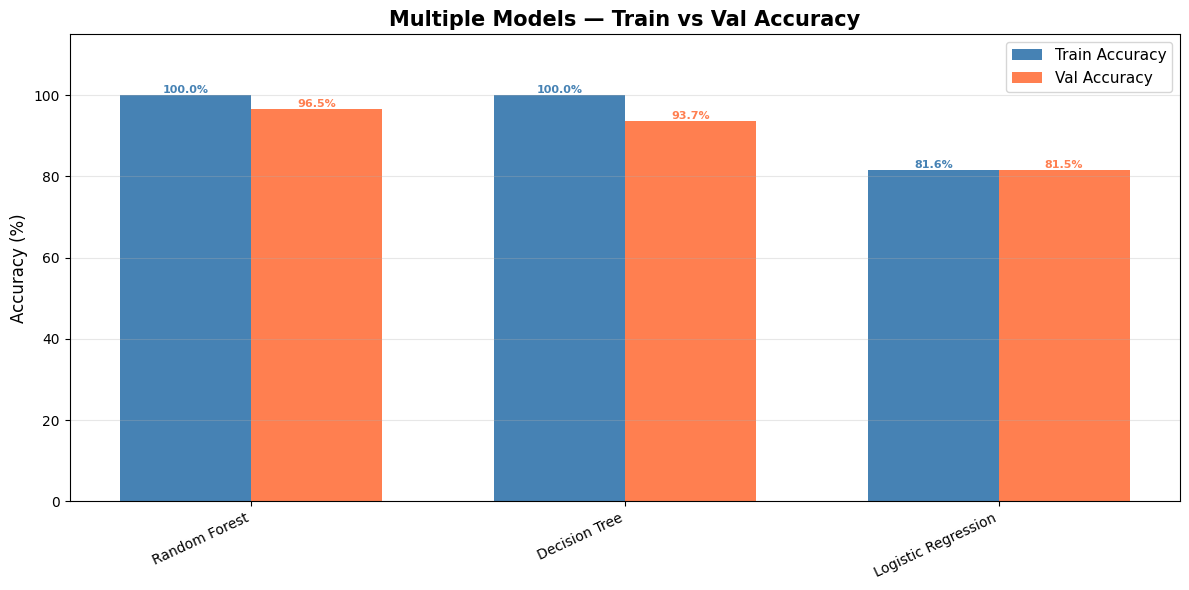

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

models = {
    'Decision Tree':        DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest':        RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, n_jobs=-1),
    # 'Gradient Boosting':    GradientBoostingClassifier(random_state=42, n_estimators=100),
    # 'AdaBoost':             AdaBoostClassifier(random_state=42, n_estimators=100),
    'Logistic Regression':  LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    # # 'KNN':                  KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    # 'Naive Bayes':          GaussianNB(),
    # # 'SVM':                  SVC(random_state=42, class_weight='balanced', probability=True),
}

results = []

for name, mdl in models.items():
    print(f"Training: {name} ...", end=' ')
    mdl.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, mdl.predict(X_train))
    val_acc   = accuracy_score(y_val,   mdl.predict(X_val))

    results.append({
        'Model':          name,
        'Train Accuracy': round(train_acc * 100, 2),
        'Val Accuracy':   round(val_acc   * 100, 2)
    })
    print(f"Done ✅  Val Acc: {val_acc:.2%}")

results_df = pd.DataFrame(results).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
results_df.index += 1
print("\n")
print("=" * 52)
print("         MODEL COMPARISON TABLE")
print("=" * 52)
print(results_df.to_string())
print("=" * 52)
print(f"\n🏆 Best Model: {results_df.iloc[0]['Model']}  →  {results_df.iloc[0]['Val Accuracy']}%")

# ── Bar Graph ──
fig, ax = plt.subplots(figsize=(12, 6))

x       = np.arange(len(results_df))
width   = 0.35

bars1 = ax.bar(x - width/2, results_df['Train Accuracy'], width, label='Train Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, results_df['Val Accuracy'],   width, label='Val Accuracy',   color='coral')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8, color='steelblue', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8, color='coral', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=10)
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Multiple Models — Train vs Val Accuracy', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Decision Tree
              precision    recall  f1-score   support

     at-risk       0.93      0.89      0.91      8000
         fit       0.94      0.97      0.95      7961
   unhealthy       0.94      0.95      0.95      8000

    accuracy                           0.94     23961
   macro avg       0.94      0.94      0.94     23961
weighted avg       0.94      0.94      0.94     23961



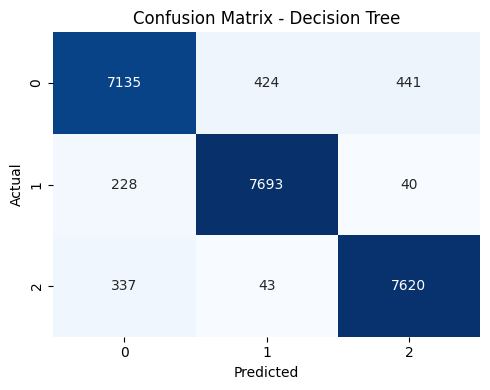


Random Forest
              precision    recall  f1-score   support

     at-risk       0.96      0.94      0.95      8000
         fit       0.98      0.98      0.98      7961
   unhealthy       0.96      0.97      0.97      8000

    accuracy                           0.97     23961
   macro avg       0.97      0.97      0.97     23961
weighted avg       0.97      0.97      0.97     23961



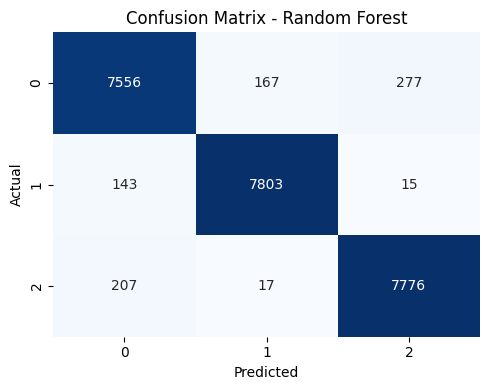


Logistic Regression
              precision    recall  f1-score   support

     at-risk       0.80      0.66      0.72      8000
         fit       0.80      0.90      0.84      7961
   unhealthy       0.85      0.89      0.87      8000

    accuracy                           0.82     23961
   macro avg       0.81      0.82      0.81     23961
weighted avg       0.81      0.82      0.81     23961



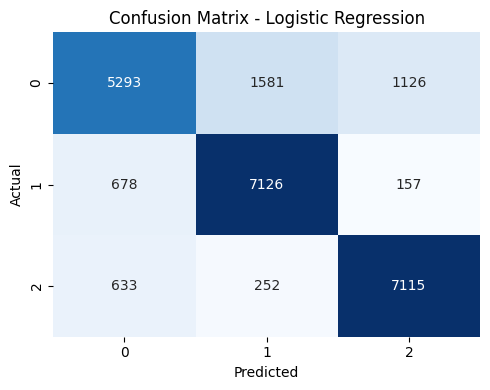

In [163]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
for name, mdl in models.items():
    print(f"\n{'='*70}")
    print(name)
    print('='*70)
    y_pred = mdl.predict(X_val)
    print(classification_report(y_val, y_pred))
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

### Confusion Matrix
A confusion matrix is a table used to describe the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class.

### Classification Report
The classification report provides precision, recall, and F1-score for each class, along with overall accuracy. Precision is the ratio of correctly predicted positive observations to the total predicted positives. Recall is the ratio of correctly predicted positive observations to all observations in the actual class. F1-score is the weighted average of Precision and Recall.

# 📈 Model Evaluation
This section provides a detailed evaluation of each trained model using classification reports and confusion matrices on the validation set. These metrics offer deeper insights into model performance beyond just accuracy, highlighting precision, recall, and F1-score for each class.

In [164]:
from sklearn.ensemble import RandomForestClassifier
import pickle
model=RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, n_jobs=-1)

model.fit(X_train, y_train)
pickle.dump(model, open("model.pkl", "wb"))
print("RandomForestClassifier Model saved!")

RandomForestClassifier Model saved!


# 🏆 Final Model Selection
Based on the evaluation results, the Random Forest Classifier achieved the highest validation accuracy and balanced performance across classes. Therefore, this cell retrains the Random Forest model on the full training data and saves it. Saving the model allows for its deployment and use for future predictions without needing to retrain.

In [165]:
print(train['health_condition'].value_counts())

health_condition
unhealthy    40000
at-risk      40000
fit          39803
Name: count, dtype: int64


### Final Class Distribution After Balancing
This cell displays the final class distribution of the `health_condition` target variable in the `train` DataFrame after balancing. This confirms the successful application of the balancing technique.

In [166]:
def predict_health():
    import pickle
    import pandas as pd

    # Model aur scaler dono load karo
    model  = pickle.load(open("model.pkl",  "rb"))
    scaler = pickle.load(open("scaler.pkl", "rb"))

    # Clearly alag alag logon ka data
    # FIT     → high steps, low bmi, good sleep, active, no smoking
    # AT-RISK → medium values, moderate activity
    # UNHEALTHY → low steps, high bmi, poor sleep, sedentary, smoking
    sample_data = pd.DataFrame({
        #                        FIT    FIT    FIT    AT     AT     AT     AT     UNH    UNH    UNH
        'sleep_duration':       [8.0,   7.8,   8.2,   6.5,   4.5,   5.8,   6.2,   4.5,   4.0,   3.8],
        'heart_rate':           [58,    60,    55,    75,    100,    80,    72,    95,    100,   105 ],
        'bmi':                  [19.5,  21.0,  20.0,  25.5,  38.0,  27.0,  24.5,  35.0,  38.0,  40.0],
        'calorie_expenditure':  [3000,  2900,  3100,  2100,  1100,  1900,  2200,  1200,  1100,  1000],
        'step_count':           [13000, 12000, 14000, 6000,  5200,  5000,  6500,  1500,  1200,  1000],
        'exercise_duration':    [70,    65,    75,    30,    4,    25,    32,    5,     4,     3   ],
        'water_intake':         [3.2,   3.0,   3.5,   2.0,   0.7,   1.8,   2.1,   0.8,   0.7,   0.6],
        'diet_type':            [0,     0,     3,     0,     1,     1,     0,     1,     1,     1   ],
        'stress_level':         [2,     2,     2,     3,     1,     1,     3,     1,     1,     1   ],
        'sleep_quality':        [2,     2,     2,     1,     1,     3,     1,     3,     3,     3   ],
        'physical_activity_level':[1,   1,     1,     2,     2,     3,     2,     3,     3,     3   ],
        'smoking_alcohol':      [1,     1,     1,     2,     1,     3,     1,     3,     3,     3   ],
        'gender':               [1,     2,     2,     1,     2,     2,     2,     1,     2,     1   ]
    })

    # Scaler lagao — model scaled data pe train hua tha
    sample_scaled  = scaler.transform(sample_data)
    predictions    = model.predict(sample_scaled)

    labels = ['FIT 1','FIT 2','FIT 3',
              'AT-RISK 1','AT-RISK 2','AT-RISK 3','AT-RISK 4',
              'UNHEALTHY 1','UNHEALTHY 2','UNHEALTHY 3']

    print("=" * 50)
    print("        PREDICTIONS — 10 Log")
    print("=" * 50)
    for i, (label, pred) in enumerate(zip(labels, predictions)):
        if pred == 'fit':
            status = "✅ Fit"
        elif pred == 'at-risk':
            status = "⚠️  At-Risk"
        else:
            status = "❌ Unhealthy"
        print(f"  {label:<14} →  {status}")

    print("=" * 50)
    print("Summary:")
    for lbl, count in pd.Series(predictions).value_counts().items():
        print(f"  {lbl}: {count} log")

    return predictions

predictions = predict_health()

        PREDICTIONS — 10 Log
  FIT 1          →  ✅ Fit
  FIT 2          →  ✅ Fit
  FIT 3          →  ✅ Fit
  AT-RISK 1      →  ⚠️  At-Risk
  AT-RISK 2      →  ❌ Unhealthy
  AT-RISK 3      →  ❌ Unhealthy
  AT-RISK 4      →  ⚠️  At-Risk
  UNHEALTHY 1    →  ❌ Unhealthy
  UNHEALTHY 2    →  ❌ Unhealthy
  UNHEALTHY 3    →  ❌ Unhealthy
Summary:
  unhealthy: 5 log
  fit: 3 log
  at-risk: 2 log


# 🚀 Prediction on New Data
This section defines a function `predict_health()` that loads the previously saved model and scaler. It then uses them to make predictions on new, unseen sample data. This demonstrates how the trained model can be used for inference in a real-world scenario.

In [167]:
train['health_condition'].value_counts()

,count
health_condition,
unhealthy,40000
at-risk,40000
fit,39803


# 📌 Conclusion
*   **Data Loading and Initial Exploration**: Loaded train and test datasets, examined their structure, and identified missing values.
*   **Data Cleaning**: Handled outliers in numerical features using IQR capping and imputed missing values in both numerical (median) and categorical ("Unknown") columns.
*   **Feature Engineering**: Dropped non-predictive 'id' columns from both datasets.
*   **Categorical Encoding**: Applied Label Encoding to transform categorical features into numerical representations.
*   **Data Splitting and Scaling**: Divided the data into training and validation sets and scaled numerical features using `StandardScaler`.
*   **Model Training and Evaluation**: Trained and evaluated Decision Tree, Random Forest, and Logistic Regression models. Random Forest showed the best performance with a validation accuracy of 96.55%.
*   **Model Saving**: The best-performing model (Random Forest) and the `StandardScaler` were saved for future use.
*   **Prediction on New Data**: Demonstrated the loaded model's capability to predict health conditions for new sample data.